# Olist ECデータ分析

ブラジルのECプラットフォーム「Olist」の公開データを使用し、売上の特徴と商品同士の購買関係を分析します。EC事業者から、販売実績をもとに今後の販売施策を検討する依頼を受けた想定です。

## 分析の目的

1. 月別売上を確認し、売上の変化を注文数と1注文あたり売上から把握する。
2. 地域・商品カテゴリ別の特徴を調べ、主要市場であるSPとSP以外を比較する。
3. SPで同時購入される商品ペアを調べ、関連商品レコメンドの検証候補を選定する。

分析対象は配送完了した注文です。売上は商品価格の合計とし、送料は含めません。金額の単位はBRL（ブラジルレアル）です。

## 実行環境

このNotebookはGoogle Colabでの実行を想定しています。CSVの読み込み先とグラフの保存先にはGoogle Drive内のパスを使用しているため、再実行する場合は自身の環境に合わせて変更してください。

## データの読み込みと前処理

注文データと注文明細の件数・重複・対応関係を確認し、売上分析の対象を配送完了（delivered）の注文に絞ります。

In [1]:
# Google Driveをマウントする
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# データの場所と画像の保存先を設定する
import os
data_path = "/content/drive/MyDrive/olist-ecommerce-analysis/data"
os.makedirs("/content/drive/MyDrive/olist-ecommerce-analysis/images",exist_ok=True)
os.listdir(data_path)

['olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_customers_dataset.csv',
 'product_category_name_translation.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_orders_dataset.csv']

CSVデータをインポートします。

In [3]:
import pandas as pd

orders_df = pd.read_csv(
    f"{data_path}/olist_orders_dataset.csv"
)

order_items_df = pd.read_csv(
    f"{data_path}/olist_order_items_dataset.csv"
)

各CSVデータの項目を確認します。

In [4]:
print("orders")
print(orders_df.columns.to_list())

print("\norder_items")
print(order_items_df.columns.to_list())

orders
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

order_items
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


データの行数を確認します

In [5]:
print("orders_df:", len(orders_df))
print("order_items_df:", len(order_items_df))

orders_df: 99441
order_items_df: 112650


注文情報データは99,441行、注文明細・商品情報データは112,650行でした。

order_idが何種類あるか確認します。

In [6]:
# 重複を除いたorder_idの種類数を数える
print("orders_dfのorder_id数:", orders_df["order_id"].nunique())
print("order_items_dfのorder_id数:", order_items_df["order_id"].nunique())

orders_dfのorder_id数: 99441
order_items_dfのorder_id数: 98666


order_idが重複しているか確認します。

In [7]:
print("orders_df")
print(orders_df["order_id"].duplicated().sum())

print("order_items_df")
print(order_items_df["order_id"].duplicated().sum())

orders_df
0
order_items_df
13984


ordersでは1つの注文につき1行、
order_itemsでは1つの注文につき複数行になることがあることが確認できました。

実際の注文を見てみます。

In [8]:
items_per_order = (
    order_items_df
    .groupby("order_id")
    .size()
    .sort_values(ascending=False)
)

items_per_order.head(10)

,0
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15
9bdc4d4c71aa1de4606060929dee888c,14
73c8ab38f07dc94389065f7eba4f297a,14
37ee401157a3a0b28c9c6d0ed8c3b24b,13
2c2a19b5703863c908512d135aa6accc,12


先ほど、  
orders_dfのorder_id数: 99441  
order_items_dfのorder_id数: 98666  
と775件の差があることを確認しました。  
つまり、orders_dfには存在するが、order_items_dfには存在しない注文がある可能性があるため、次はその差を確認します。

まず、本当に775件抽出できているか確認します。

In [9]:
result_df = orders_df[~orders_df['order_id'].isin(order_items_df['order_id'])]
missing_ids = result_df['order_id'].unique()

len(result_df)

775

今回result_dfにはorders_dfの列がすべて残っているので、order_statusも入っています。
ここで、商品明細が存在しない775件は、どんな注文ステータスなのかを次に調べていきます。

In [10]:
# 存在しない775件の構成を確認する
result_df["order_status"].value_counts()

,count
order_status,
unavailable,603
canceled,164
created,5
invoiced,2
shipped,1


In [11]:
# 存在しない775件の構成割合を確認する
result_df["order_status"].value_counts(normalize=True)

,proportion
order_status,
unavailable,0.778065
canceled,0.211613
created,0.006452
invoiced,0.002581
shipped,0.001290


order_itemsに存在しない775件のうち、約77.8%がunavailable、約21.2%がcanceledであり、この2つで約99%を占めていました。  
そのため、商品明細が存在しない注文の大部分は、正常に取引が完了していない注文であると考えられます。

これから売上は時期によってどのように変化しているかを調べるにあたり、orders_dfに含まれているキャンセルされた注文まで「売上」に含めてしまう可能性があるため、order_items_dfに存在する注文のうち、canceledなどの未完了注文はどのくらいあるのか確認していきます。

In [12]:
# order_items_dfに存在するorder_idに限定して、order_statusごとの注文数を確認する
orders_with_items_df = orders_df[orders_df['order_id'].isin(order_items_df['order_id'])]

len(orders_with_items_df)

98666

order_itemsに商品明細が存在する注文は98,666件でした。

In [13]:
# order_items_dfに存在するorder_idに限定した注文状況を確認する
orders_with_items_df["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1106
canceled,461
invoiced,312
processing,301
unavailable,6
approved,2


In [14]:
# order_items_dfに存在するorder_idに限定した各注文状況の割合を確認する
orders_with_items_df["order_status"].value_counts(normalize=True)

,proportion
order_status,
delivered,0.977824
shipped,0.011210
canceled,0.004672
invoiced,0.003162
processing,0.003051
unavailable,0.000061
approved,0.000020


上記の結果より、月別の売上を調べるためにはorder_statusが配達済み（delivered）となっている注文を対象にすることにします。

In [15]:
# order_statusが"delivered"の行だけを抽出して新しいデータフレームを作成

delivered_orders_df = orders_df[
    orders_df["order_status"] == "delivered"
] .copy()

# データ件数を確認
len(delivered_orders_df)

96478

配送完了（delivered）の注文に、注文明細をorder_idで結合します。

本分析では、商品明細のpriceの合計を売上（BRL：ブラジルレアル）と定義し、送料は含めません。月別売上は、配送完了した注文を購入日時（order_purchase_timestamp）の月に集計します。

In [16]:
sales_df = pd.merge(
    delivered_orders_df,
    order_items_df,
    on="order_id",
    how="left"
)

sales_df.shape

(110197, 14)

結合した結果、110197行、14列のデータフレームになりました。  
delivered_orders_dfは96,478行でしたが、1つの注文に複数の商品明細があるため、結合後は110,197行に増えています。

次に、left joinした結果、商品明細が付かなかった行がないか確認します。  
これにより、priceが欠損していないか確認できます。

In [17]:
sales_df["price"].isna().sum()

np.int64(0)

欠損値がないことを確認できました。

次に、月別売上に進みます。  
まずはorder_purchase_timestampのデータ型を確認します。

In [18]:
sales_df["order_purchase_timestamp"].dtype

dtype('O')

Oはobject型（文字列扱い）なので、日時型に変換します。

In [19]:
sales_df["order_purchase_timestamp"] = pd.to_datetime(
    sales_df["order_purchase_timestamp"]
)

In [20]:
sales_df["order_purchase_timestamp"].dtype

dtype('<M8[ns]')

日付型に変換できたことを確認しました。  
次に、月単位で集計できる列を作ります。

In [21]:
sales_df["purchase_month"] = (
    sales_df["order_purchase_timestamp"]
    .dt.to_period("M")
)

sales_df[
    ["order_purchase_timestamp", "purchase_month"]
].head()

,order_purchase_timestamp,purchase_month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


月単位で集計できる列を作成しました。次は、purchase_monthごとにpriceを合計し、月別売上を集計します。

In [22]:
monthly_sales = (
    sales_df.groupby("purchase_month")["price"].sum()
)

monthly_sales

,price
purchase_month,
2016-09,134.97
2016-10,40325.11
2016-12,10.90
2017-01,111798.36
2017-02,234223.40
2017-03,359198.85
2017-04,340669.68
2017-05,489338.25
2017-06,421923.37


2017年は全体として売上が拡大しているように見えます。特に11月が約98.8万と大きく跳ねています。  

一方、2018年を見てみると、おおむね80万〜100万弱の範囲なので、2017年のような急成長というより、高い水準で推移しているように見えます。  

ところが、2016年見てみると、9月と12月は極端に低いこと、11月の売上データが集計されていません。  
そのため、2016年9月や12月は、本当に1ヶ月分のデータが入っているか確認する必要があります。  

そこで、月別売上のグラフを作る前に、データ期間を確認します。  
sales_df["order_purchase_timestamp"]を使って、
最も古い注文日時と最も新しい注文日時
を調べてみることにします。

In [23]:
#最も古い注文日時を表示
print(sales_df["order_purchase_timestamp"].min())

# 最も新しい注文日時を表示
print(sales_df['order_purchase_timestamp'].max())

2016-09-15 12:16:38
2018-08-29 15:00:37


最も古い注文日時は2016年9月15日 12：16であり、最も新しい注文日時は2018年8月29日 15：00でした。  

次に、2016年9月・10月・12月にはそれぞれ何件の注文があるのかも確認していきます。

In [24]:
# 月別の注文数を確認する
monthly_orders = (
    sales_df.groupby("purchase_month")["order_id"].nunique()
)

monthly_orders

,order_id
purchase_month,
2016-09,1
2016-10,265
2016-12,1
2017-01,750
2017-02,1653
2017-03,2546
2017-04,2303
2017-05,3546
2017-06,3135


2016年9月と12月の注文件数はそれぞれ1件でした。さらに11月は0件です。  
したがって、2016年のデータは継続的な注文実績として扱うには件数が非常に少なく、通常期の売上推移との単純比較には注意が必要と考えます。  

以上のことから、月別売上分析では継続的に注文データが確認できる2017年1月〜2018年8月を対象とします。

ここまで月別に集計した結果から、2017年11月は特に売り上げが伸びていることが分かりました。  
そこで、次は特に売り上げが伸びている要因について調べていきます。


## 月別売上推移の折れ線グラフを作成  

ここまで確認できたので、2017年1月〜2018年8月を対象に月別売上推移の折れ線グラフを作成します。  

まず、分析対象を作ります。

In [25]:
# 2017年1月からの月別売上データを作る
monthly_sales_analysis = monthly_sales[monthly_sales.index >= "2017-01"]
monthly_sales_analysis

,price
purchase_month,
2017-01,111798.36
2017-02,234223.40
2017-03,359198.85
2017-04,340669.68
2017-05,489338.25
2017-06,421923.37
2017-07,481604.52
2017-08,554699.70
2017-09,607399.67


In [26]:
!pip install -q japanize-matplotlib

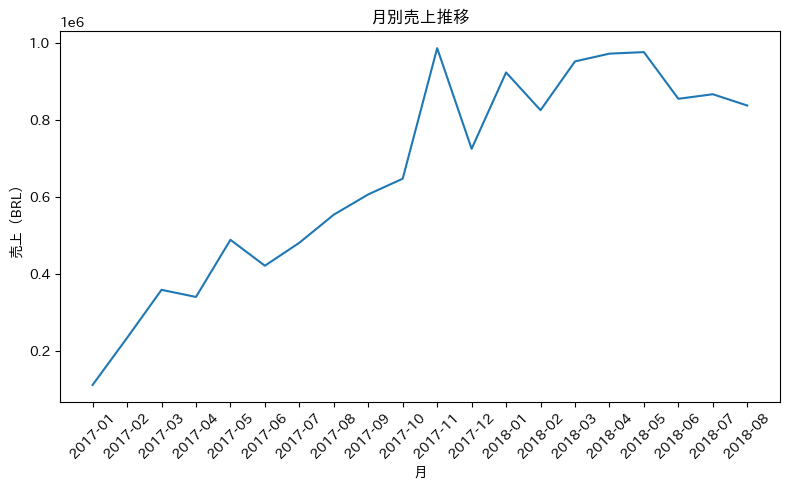

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.figure(figsize=(8,5))

plt.plot(
    monthly_sales_analysis.index.astype(str),
    monthly_sales_analysis.values
)

plt.title("月別売上推移")
plt.xlabel("月")
plt.ylabel("売上（BRL）")
plt.xticks(rotation=45)
plt.tight_layout()

# グラフを画像として保存
plt.savefig(
    "/content/drive/MyDrive/olist-ecommerce-analysis/images/monthly_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### 月別売上の分析結果
2017年1月から10月にかけて、月ごとの増減はあるものの、売上は全体として増加傾向にあります。特に2017年11月には売上が大きく増加し、約98.8万となりました。  
12月には減少したものの、10月以前と比較すると高い水準を維持しています。  

2018年1月に売上は再び増加し、2月には減少しました。  
3月から5月は約95万〜98万BRLの高水準で推移しています。その後6月に減少し、7月に小幅に回復したものの、8月には再び減少しています。

ただし、分析対象の最終注文日時は2018年8月29日であり、8月は月末までのデータが揃っていないため、前月までの売上との比較には注意が必要です。

In [28]:
monthly_sales_per_order = monthly_sales / monthly_orders
monthly_sales_per_order

,0
purchase_month,
2016-09,134.970000
2016-10,152.170226
2016-12,10.900000
2017-01,149.064480
2017-02,141.695947
2017-03,141.083602
2017-04,147.924307
2017-05,137.997250
2017-06,134.584807


### 2017年11月の売上増加の内訳

2017年10月から11月にかけて、注文数は4,478件から7,289件へ増加しました。一方、1注文あたり売上は144.76 BRLから135.51 BRLへ低下しています。

このことから、11月の売上増加は主に注文数の増加によるものと分かります。ただし、注文数が増えた背景については、キャンペーンや季節イベントなどの追加情報と照合する必要があります。

## 売上が多い地域を調べる  
月別売上グラフでは、継続的に注文が確認できる2017年1月〜2018年8月を表示しました。

ここからの地域・カテゴリ分析では、2016年分も含む配送完了96,478注文全体を対象とします。対象注文の購入日時は、2016年9月15日〜2018年8月29日です。

In [29]:
# 顧客データを読み込む
customers_df = pd.read_csv(
    f"{data_path}/olist_customers_dataset.csv"
)

customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [30]:
# customers_dfの行数を確認する
print("customers_df:", len(customers_df))

customers_df: 99441


In [31]:
# 重複を除いたcustomer_idの種類数を数える
print("customers_dfのcustomer_id数:", customers_df["customer_id"].nunique())

customers_dfのcustomer_id数: 99441


In [32]:
# customer_idが重複しているか確認
print("customers_df")
print(customers_df["customer_id"].duplicated().sum())

customers_df
0


In [33]:
# sales_dfとcustomers_dfを結合する
regional_sales_df = pd.merge(
    sales_df,
    customers_df,
    on = "customer_id",
    how = "left"
).copy()

regional_sales_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,purchase_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [34]:
# 結合によって行数が変わっていないか確認する
print("sales_df:", len(sales_df))
print("regional_salse_df:", len(regional_sales_df))

sales_df: 110197
regional_salse_df: 110197


行数が変わっていないことを確認しました。

In [35]:
# customer_stateに欠損がないか確認する
regional_sales_df["customer_state"].isna().sum()

np.int64(0)

欠損がないことを確認しました。したがって、すべての商品明細について州情報を取得できたことになります。  
それでは、地域ごとの売上を集計していきます。

In [36]:
# customer_stateごとにpriceを合計
customers_state_sales = (
    regional_sales_df.groupby("customer_state")["price"].sum().sort_values(ascending=False)
)

customers_state_sales

,price
customer_state,
SP,5067633.16
RJ,1759651.13
MG,1552481.83
RS,728897.47
PR,666063.51
SC,507012.13
BA,493584.14
DF,296498.41
GO,282836.70


次に、売上構成比を確認します。

In [37]:
# 州別売上構成比を確認
state_sales_share = (
    customers_state_sales / customers_state_sales.sum() * 100
)

state_sales_share

,price
customer_state,
SP,38.328736
RJ,13.309015
MG,11.742102
RS,5.512972
PR,5.037731
SC,3.834756
BA,3.733194
DF,2.242548
GO,2.139218


上位3つの州（SP、RJ、MG）だけでどのくらいになるか確認します。

In [38]:
state_sales_share.head(3).sum()

np.float64(63.379853404524674)

上位3つの州だけで約63.4％を占めていることが分かりました。  
次はこの内訳について確認していきます。

In [39]:
state_orders = (
    regional_sales_df.groupby("customer_state")["order_id"].nunique().sort_values(ascending=False)

)

state_orders

,order_id
customer_state,
SP,40501
RJ,12350
MG,11354
RS,5345
PR,4923
SC,3546
BA,3256
DF,2080
ES,1995


売上上位3州は注文数でも上位3州です。  
特にSPは注文数がかなり多いので、SPの売上が突出している主な要因として注文数の多さが関係していそうです。  
次は州別の1注文あたりの売上を確認していきます。

In [40]:
# 州別の1注文あたりの売上を確認
state_sales_per_order = customers_state_sales / state_orders
state_sales_per_order.sort_values(ascending=False)

,0
customer_state,
PB,217.769478
AP,199.624030
AC,199.137125
AL,198.629018
RO,187.994897
PA,184.429799
PI,177.985294
TO,176.651496
RN,173.218692


SPは、売上1位・注文数1位なのに、1注文あたり売上は27州中最下位という結果になりました。  
逆に1注文あたり売上1位のPBは、約217.77ですが、注文数はわずか517件でした。  


### ここまでの分析結果まとめ
地域別売上ではSPが全体の約38.3%を占めて最も高く、RJ・MGを含む上位3州で約63.4%を占めています。売上上位3州は注文数でも上位3州でした。  
一方、1注文あたり売上ではSPが約125.1と27州中最も低く、売上規模と1注文あたり売上の順位には大きな違いが見られました。

次は、州別の売上をグラフ化していきます。

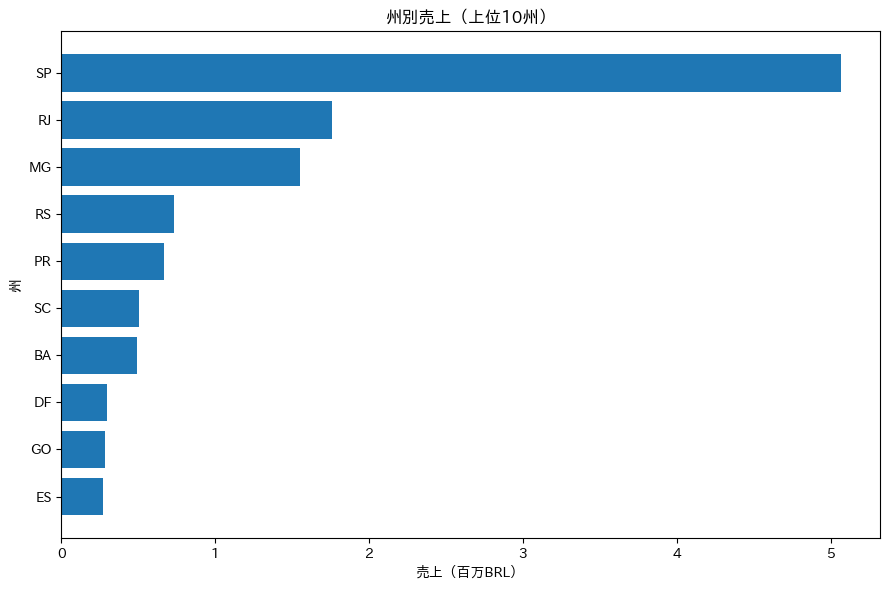

In [41]:
# 上位10件のみを取り出す
top10_state_sales = customers_state_sales.head(10)

# グラフを作成
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(9, 6))

plt.barh(
    top10_state_sales.index,
    top10_state_sales.values
)

plt.title("州別売上（上位10州）")
plt.xlabel("売上（百万BRL）")
plt.ylabel("州")

# 売上1位を上に表示
plt.gca().invert_yaxis()

# 横軸をカンマ区切りにする
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:.0f}")
)

plt.tight_layout()

# imagesフォルダに保存
plt.savefig(
    "/content/drive/MyDrive/olist-ecommerce-analysis/images/sales_by_state_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# 上位10州で売上全体の何％を占めるかを確認する。
state_sales_share.head(10).sum()

np.float64(87.91214001088719)

### 地域別売上の分析結果

*   SPの売上は5,067,633で最も高く、2位のRJ（1,759,651）の約2.9倍となっている。
*   売上構成比では、SPだけで全体の38.3%を占めている。
*   SP・RJ・MGの上位3州で売上全体の63.4%、上位10州では87.9%を占めており、売上は上位地域に集中している。  

SPは売上が最も高い一方、1注文あたり売上は約125と27州の中で最も低いです。  
しかし、注文数は40,501件と2位のRJ（12,350件）の約3.3倍に達しています。  
したがって、SPの高い売上は1注文あたり売上の高さではなく、注文数の多さによって支えられていると考えられます。



## 顧客の購買行動にはどのような特徴があるか調べる

まず、顧客数を確認します。

In [43]:
# 重複を除いたcustomer_unique_idの数を確認
customer_count = regional_sales_df["customer_unique_id"].nunique()
print("regional_sales_dfのcustomer_unique_idの数：", customer_count)

regional_sales_dfのcustomer_unique_idの数： 93358


全体の顧客数は93,358人であることが確認できました。  
次は1顧客あたりの注文数を確認していきます。

In [44]:
# 各顧客が何回注文したかを表す表を作成
orders_per_customer = (
    regional_sales_df.groupby("customer_unique_id")["order_id"].nunique()
)

orders_per_customer

,order_id
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1
...,...
fffcf5a5ff07b0908bd4e2dbc735a684,1
fffea47cd6d3cc0a88bd621562a9d061,1
ffff371b4d645b6ecea244b27531430a,1


In [45]:
# 注文回数ごとの顧客数を確認する
print(orders_per_customer.value_counts().sort_index())

order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


In [46]:
# 2回以上注文した顧客数を求める
repeat_customer_count = (orders_per_customer >= 2).sum()
repeat_customer_count

np.int64(2801)

2回以上注文した顧客は2,801人であることを確認しました。  
次に全体のうち、2回以上注文している顧客の割合を求めます。

In [47]:
# 2回以上注文している顧客の割合を求める
repeat_customers_share = repeat_customer_count / customer_count * 100
repeat_customers_share

np.float64(3.0002784978255748)

2回以上注文している顧客の割合は約3.0％でした。  
つまり、今回の「配送完了注文」を対象にすると、

*   ユニーク顧客数：93,358人
*   2回以上注文：2,801人
*   2回以上注文した顧客の割合：約3.0%
*   逆に、1回のみ注文した顧客は約97.0%  

ということが分かりました。



## 1顧客あたり売上を調べる

まずは各顧客の売上合計を求めます。

In [48]:
sales_per_customer = (
    regional_sales_df.groupby("customer_unique_id")["price"].sum().sort_values(ascending=False)
)

sales_per_customer

,price
customer_unique_id,
0a0a92112bd4c708ca5fde585afaa872,13440.00
da122df9eeddfedc1dc1f5349a1a690c,7388.00
763c8b1c9c68a0229c42c9fc6f662b93,7160.00
dc4802a71eae9be1dd28f5d788ceb526,6735.00
459bef486812aa25204be022145caa62,6729.00
...,...
cf3839da0d9492ad151690b65f45d800,2.99
bd06ce0e06ad77a7f681f1a4960a3cc6,2.29
317cfc692e3f86c45c95697c61c853a6,2.20


次に1顧客あたりの平均売上を求めます。

In [49]:
average_sales_per_customer = sales_per_customer.mean()
average_sales_per_customer

np.float64(141.62147978748473)

平均141.62ということが分かりました。  
しかし、この平均値だけで「一般的な顧客は140程度購入している」と判断してよいか分からないため、中央値も確認します。

In [50]:
median_sales_per_customer = sales_per_customer.median()
median_sales_per_customer

89.73

*   1顧客あたり平均売上：141.62
*   1顧客あたり売上中央値：89.73  

ということが分かりました。  

平均値のほうが中央値より約52高いので、一部の売上額が大きい顧客によって平均値が引き上げられている可能性が考えられます。

そこで、次は顧客別売上の分布を確認したいと思います。

In [51]:
sales_per_customer.describe()

,price
count,93358.000000
mean,141.621480
std,215.694014
min,0.850000
25%,47.650000
50%,89.730000
75%,154.737500
max,13440.000000


今回の結果から、顧客別売上の75%点は154.74である一方、最大値は13,440であり、75%点の約86.9倍となっています。  
また、平均値141.62が中央値89.73を上回っており、一部に売上額が非常に大きい顧客が存在することが確認できました。

## どの商品カテゴリが売上に貢献しているか調べる

In [52]:
# 商品データを読み込む
products_df = pd.read_csv(
    f"{data_path}/olist_products_dataset.csv"
)

products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


まず、商品データに含まれている項目を確認します。

In [53]:
# 商品データの項目を確認する
products_df.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

商品データには、10項目のデータが含まれていることが確認できました。  
次に、商品データの行数、product_idの数、product_idの重複数を確認します。

In [54]:
# 商品データの行数、product_idの数、product_idの重複数を確認する
print("行数：", len(products_df))
print("product_idの数：", products_df["product_id"].nunique())
print("product_idの重複数", products_df["product_id"].duplicated().sum())

行数： 32951
product_idの数： 32951
product_idの重複数 0


行数はproduct_idの数と一致し、product_idの重複がないため、1行＝1商品であることが確認できました。  
次はproduct_category_nameに欠損値がないか確認します。

In [55]:
# product_category_nameの欠損値を確認
products_df["product_category_name"].isna().sum()

np.int64(610)

product_category_nameに欠損値が610件あることが確認できたので、次は欠損値が今回分析対象としている売上のどの程度を占めているか確認し、扱いを決めます。

In [56]:
product_sales_df = pd.merge(
    sales_df,
    products_df,
    on="product_id",
    how="left"
).copy()

product_sales_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,purchase_month,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,8.72,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,22.76,2018-07,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,19.22,2018-08,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,27.20,2017-11,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,2018-02,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


結合後のデータの行数が110,197行から増減していないか確認します。

In [57]:
print("salse_dfの行数:", len(sales_df))
print("product_salse_dfの行数：", len(product_sales_df))

salse_dfの行数: 110197
product_salse_dfの行数： 110197


正常に結合されたことが確認できました。  
先ほどProducts全体では、カテゴリが欠損している商品が610商品ありました。  
今回重要なのは、そのうち実際に配送完了注文に登場した商品明細が何件あるかなので、結合後のデータで確認します。

In [58]:
# カテゴリ不明な商品明細が何件あるか確認
product_sales_df["product_category_name"].isna().sum()

np.int64(1537)

In [59]:
# カテゴリ不明な商品の売上を確認
unknown_category_sales = product_sales_df[
    product_sales_df["product_category_name"].isna()
]["price"].sum()
unknown_category_sales

np.float64(170726.63)

In [60]:
# 全売り上げを求める
total_sales = product_sales_df["price"].sum()
total_sales

np.float64(13221498.110000001)

In [61]:
# カテゴリ不明な商品の売上構成比を求める
unknown_category_sales_share = unknown_category_sales / total_sales * 100
unknown_category_sales_share

np.float64(1.2912805234292772)

商品カテゴリが欠損している商品について確認したところ、該当商品の売上は全体の約1.29%のため、商品カテゴリ別の分析からは除外することにします。

それでは、カテゴリ別売上を求めていきます

In [62]:
# カテゴリごとの売上合計を求める
category_sales = (
    product_sales_df.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

,price
product_category_name,
beleza_saude,1233131.72
relogios_presentes,1166176.98
cama_mesa_banho,1023434.76
esporte_lazer,954852.55
informatica_acessorios,888724.61
...,...
flores,1110.04
casa_conforto_2,760.27
cds_dvds_musicais,730.00


73カテゴリあり、beleza_saudeが最も売り上げが高い結果になりました。  
次はどのカテゴリが売上に貢献しているか確認していきます。

In [63]:
# カテゴリごとの売上構成比を求める
category_sales_share = (category_sales / category_sales.sum() * 100)
category_sales_share

,price
product_category_name,
beleza_saude,9.448727
relogios_presentes,8.935694
cama_mesa_banho,7.841948
esporte_lazer,7.316445
informatica_acessorios,6.809748
...,...
flores,0.008506
casa_conforto_2,0.005825
cds_dvds_musicais,0.005594


In [64]:
category_sales_share.head(10)

,price
product_category_name,
beleza_saude,9.448727
relogios_presentes,8.935694
cama_mesa_banho,7.841948
esporte_lazer,7.316445
informatica_acessorios,6.809748
moveis_decoracao,5.455062
utilidades_domesticas,4.717182
cool_stuff,4.675617
automotivo,4.436264


In [65]:
# 上位10カテゴリそれぞれの構成比を求める
category_sales_share.head(10).sum()

np.float64(63.247864255761215)

今回の結果から  
*   売上が最も高いカテゴリはbeleza_saudeで、カテゴリ判明分の売上の約9.45%を占める。
*   2位はrelogios_presentes（約8.94%）、3位はcama_mesa_banho（約7.84%）となっている。
*   上位10カテゴリを合計すると売上の約63.25%を占める。
*   1カテゴリだけで10%以上を占めるカテゴリはなく、地域別売上ほど特定の上位カテゴリに売上が集中していない。  

ということが分かりました。  
次はなぜそのカテゴリの売上が高いか調べていきます。



In [66]:
# カテゴリごとの注文数を求める
category_orders = (
    product_sales_df.groupby("product_category_name")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

category_orders.head(10)

,order_id
product_category_name,
cama_mesa_banho,9272
beleza_saude,8647
esporte_lazer,7530
informatica_acessorios,6530
moveis_decoracao,6307
utilidades_domesticas,5743
relogios_presentes,5495
telefonia,4093
automotivo,3810


売上ランキングと注文数ランキングに違いができていることが確認できました。  
特にrelogios_presentesは売上は2位なのに、注文数は7位という結果でした。  
逆にcama_mesa_banhoは、注文数1位なのに売上は3位です。
ここから、カテゴリによって1注文あたりの売上が違う可能性が考えられます。  
次は、カテゴリ別1注文あたり売上を調べていきます。

カテゴリ別の1注文あたり売上は、「そのカテゴリの商品売上 ÷ そのカテゴリの商品を含む注文数」で計算します。

複数カテゴリの商品を含む注文は、それぞれのカテゴリの注文数に1件として数えます。ただし、売上には各カテゴリの商品金額だけを含めます。そのため、この指標は、そのカテゴリを購入した注文の総額の平均とは異なります。

後半のSPとSP以外のカテゴリ比較でも、同じ定義を使用します。

In [67]:
# カテゴリ別1注文あたり売上を求める
category_sales_per_order = category_sales / category_orders
category_sales_per_order.sort_values(ascending=False)

,0
product_category_name,
pcs,1235.503616
portateis_casa_forno_e_cafe,647.077222
eletrodomesticos_2,475.568062
agro_industria_e_comercio,398.678531
portateis_cozinha_e_preparadores_de_alimentos,302.586923
...,...
eletronicos,61.598701
cds_dvds_musicais,60.833333
fraldas_higiene,60.031600


In [68]:
# カテゴリ名、売上、注文数、比率に絞って表示する
category_analysis = pd.concat(
    [
        category_sales,
        category_orders,
        category_sales_per_order,

    ],
    axis=1
)

category_analysis.head(10)

,price,order_id,0
product_category_name,,,
beleza_saude,1233131.72,8647,142.608040
relogios_presentes,1166176.98,5495,212.225110
cama_mesa_banho,1023434.76,9272,110.379072
esporte_lazer,954852.55,7530,126.806448
informatica_acessorios,888724.61,6530,136.098715
moveis_decoracao,711927.69,6307,112.878974
utilidades_domesticas,615628.69,5743,107.196359
cool_stuff,610204.10,3559,171.453807
automotivo,578966.65,3810,151.959751


In [69]:
category_analysis.columns = [
    "sales",
    "orders",
    "sales_per_order"
]

category_analysis.head(10)

,sales,orders,sales_per_order
product_category_name,,,
beleza_saude,1233131.72,8647,142.608040
relogios_presentes,1166176.98,5495,212.225110
cama_mesa_banho,1023434.76,9272,110.379072
esporte_lazer,954852.55,7530,126.806448
informatica_acessorios,888724.61,6530,136.098715
moveis_decoracao,711927.69,6307,112.878974
utilidades_domesticas,615628.69,5743,107.196359
cool_stuff,610204.10,3559,171.453807
automotivo,578966.65,3810,151.959751


beleza_saude：   
売上が1位、注文数が2位であり、1注文あたり売上も142.61と一定の水準にあります。注文数と1注文あたり売上の両方によって、高い売上を維持していると考えられます。

relogios_presentes：  
注文数は5,495件で売上上位10カテゴリの中では比較的少ない一方、1注文あたり売上は212.23と上位10カテゴリの中で最も高いです。そのため、1注文あたり売上の高さが売上2位につながっていると考えられます。  

cama_mesa_banho：  
1注文あたり売上は110.38と売上上位カテゴリの中では比較的低い一方、注文数は9,272件で最も多いです。そのため、注文数の多さによって高い売上を生み出していると考えられます。

上位10位のカテゴリの売上について確認できたので、次は売上への貢献度が低い商品カテゴリは何か調べていきます。

In [70]:
# 下位10位のカテゴリを表示する
category_analysis.tail(10)

,sales,orders,sales_per_order
product_category_name,,,
fashion_esporte,2094.52,26,80.558462
la_cuisine,2054.99,13,158.076154
artes_e_artesanato,1814.01,23,78.870000
fraldas_higiene,1500.79,25,60.031600
pc_gamer,1306.95,7,186.707143
flores,1110.04,29,38.277241
casa_conforto_2,760.27,24,31.677917
cds_dvds_musicais,730.00,12,60.833333
fashion_roupa_infanto_juvenil,519.95,7,74.278571


売上下位10カテゴリはいずれも注文数が29件以下であり、売上への貢献度が低いカテゴリでは注文数も少ない傾向が確認されました。  
一方、1注文あたり売上にはカテゴリ間で差があり、pc_gamerは186.71、casa_conforto_2は31.68となっています。

次から商品カテゴリ分析のグラフを作成していきますが、その前に、カテゴリ名がポルトガル語ですので、英語に直していきます。

ポルトガル語→英語への翻訳CVSデータを読み込みます

In [71]:
# ポルトガル語→英語への翻訳CVSデータ読み込み
category_translation_df = pd.read_csv(
    f"{data_path}/product_category_name_translation.csv"
)

category_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [72]:
# 翻訳データの項目を確認
category_translation_df.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [73]:
# category_translation_dfは1行＝何かを確認する
print("行数：", len(category_translation_df))

print(
    "product_category_nameの数：",
    category_translation_df["product_category_name"].nunique()
)

print(
    "product_category_nameの重複：",
    category_translation_df["product_category_name"].duplicated().sum()
)

行数： 71
product_category_nameの数： 71
product_category_nameの重複： 0


category_salesでは73カテゴリありましたが、翻訳表には71データしかありません。  
商品カテゴリ73種類 − 翻訳表71種類 = 最大2カテゴリ  
について英語訳が用意されていない可能性があるため確認していきます。

In [74]:
# 英語訳が用意されていないカテゴリを確認する
product_sales_df[
    ~product_sales_df["product_category_name"].isin(
        category_translation_df["product_category_name"]
    )
]["product_category_name"].unique()

array([nan, 'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'],
      dtype=object)

nanは以前確認したカテゴリ欠損なので、実際に「カテゴリ名は存在するが翻訳表にない」のは次の2カテゴリです。  

*   portateis_cozinha_e_preparadores_de_alimentos
*   pc_gamer  

これで、商品データ73カテゴリに対して翻訳表71カテゴリだった理由も確認できました。



次は翻訳表を結合します。

In [75]:
# product_salse_dfとcategory_translation_dfを結合する
product_sales_en_df = pd.merge(
    product_sales_df,
    category_translation_df,
    on="product_category_name",
    how="left"
).copy()

product_sales_en_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,purchase_month,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,2017-10,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,2018-07,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,2018-08,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,2017-11,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,2018-02,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [76]:
# product_category_name_englishが欠損している行がないか確認
product_sales_en_df[
    product_sales_en_df["product_category_name_english"].isna()
][
    ["product_category_name", "product_category_name_english"]
].value_counts(dropna=False)

,,count
product_category_name,product_category_name_english,
NaN,NaN,1537
portateis_cozinha_e_preparadores_de_alimentos,NaN,14
pc_gamer,NaN,8


In [77]:
# 英訳がない場合だけ元のポルトガル語名を使う
product_sales_en_df["category_name"] = (
    product_sales_en_df["product_category_name_english"]
    .fillna(product_sales_en_df["product_category_name"])
)

product_sales_en_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,stationery


category_nameは分析・グラフ表示用の統一されたカテゴリ名になりました。

## 上位10カテゴリのグラフを作成する

In [78]:
# 英語名で集計した売上上位10カテゴリを作る
category_sales_en = (
    product_sales_en_df.groupby("category_name")["price"].sum().sort_values(ascending=False)
)

category_sales_en

,price
category_name,
health_beauty,1233131.72
watches_gifts,1166176.98
bed_bath_table,1023434.76
sports_leisure,954852.55
computers_accessories,888724.61
...,...
flowers,1110.04
home_comfort_2,760.27
cds_dvds_musicals,730.00


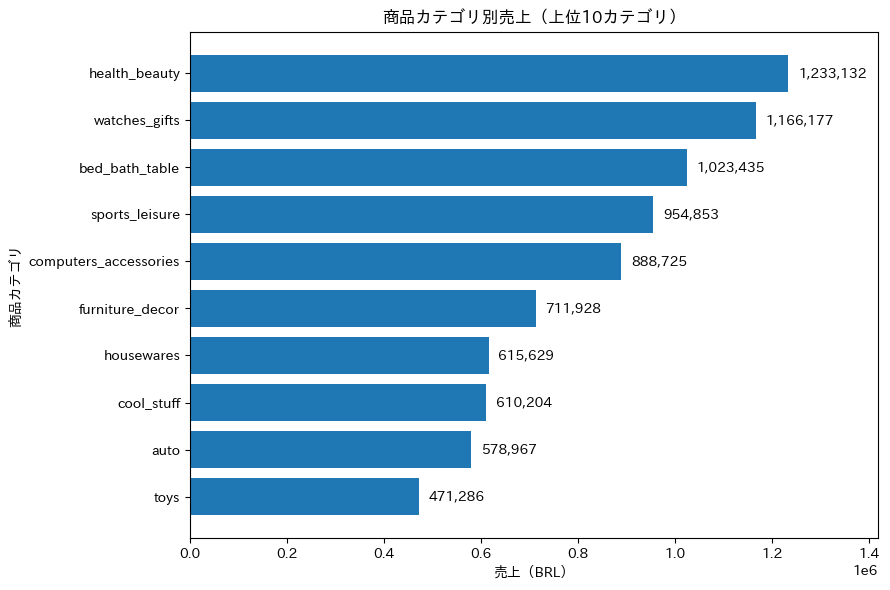

In [79]:
# category_sales_enから上位10カテゴリを取り出す
top10_category_sales = category_sales_en.head(10).sort_values(ascending=True)

# グラフ作成
plt.figure(figsize=(9, 6))

plt.barh(
    top10_category_sales.index,
    top10_category_sales.values
)

plt.title("商品カテゴリ別売上（上位10カテゴリ）")
plt.xlabel("売上（BRL）")
plt.ylabel("商品カテゴリ")

# 各棒の右側に売上を表示
for i, value in enumerate(top10_category_sales.values):
    plt.text(
        value + 20000,
        i,
        f"{value:,.0f}",
        va="center"
    )

plt.xlim(0, top10_category_sales.max() * 1.15)
plt.tight_layout()

# imagesフォルダに保存
plt.savefig(
    "/content/drive/MyDrive/olist-ecommerce-analysis/images/sales_by_category_top10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 売上拡大のために新規獲得とリピーター獲得のどちらに注目するか検討する

すでに確認できているのは、
- 配送完了注文をした顧客：93,358人
- 2回以上注文した顧客：2,801人
- リピーター：約3.0%
- 1回のみ：約97.0%  

でした。  

ただ、「3%しかいない」だけではリピーターが売上にとって重要かどうかは分かりません。  
そこで次は、顧客を「1回購入」と「リピーター」に分けて売上を比較します。

最初は顧客タイプを作ります。

In [80]:
# 顧客タイプ作成
import numpy as np

customer_type = np.where(
    orders_per_customer > 1,
    "Repeat",
    "One-time"
)

customer_type

array(['One-time', 'One-time', 'One-time', ..., 'One-time', 'One-time',
       'One-time'], dtype='<U8')

次に、顧客単位のDataFrameを作ります。

In [81]:
customer_summary = pd.DataFrame({
    "orders": orders_per_customer,
    "customer_type": customer_type
})

customer_summary.head()

,orders,customer_type
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,One-time
0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-time
0000f46a3911fa3c0805444483337064,1,One-time
0000f6ccb0745a6a4b88665a16c9f078,1,One-time
0004aac84e0df4da2b147fca70cf8255,1,One-time


In [82]:
# customer_summaryに売上列を追加する
customer_summary["sales"] = sales_per_customer
customer_summary.head()

,orders,customer_type,sales
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,One-time,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,One-time,18.90
0000f46a3911fa3c0805444483337064,1,One-time,69.00
0000f6ccb0745a6a4b88665a16c9f078,1,One-time,25.99
0004aac84e0df4da2b147fca70cf8255,1,One-time,180.00


ここから、顧客タイプ別に比較します。

In [83]:
# 顧客数と売上合計を求める
customer_type_summary = (
    customer_summary
    .groupby("customer_type")
    .agg(
        customers=("orders", "count"),
        total_sales=("sales", "sum")
    )
)

customer_type_summary

,customers,total_sales
customer_type,,
One-time,90557,12493089.36
Repeat,2801,728408.75


In [84]:
# 顧客タイプごとの売上構成比を求める
customer_type_summary["sales_share"] = (
    customer_type_summary["total_sales"] / customer_type_summary["total_sales"].sum() * 100
)

# 1人当たりの売上を求める
customer_type_summary["sales_per_customer"] = (
    customer_type_summary["total_sales"] / customer_type_summary["customers"]
)
customer_type_summary

,customers,total_sales,sales_share,sales_per_customer
customer_type,,,,
One-time,90557,12493089.36,94.490725,137.958295
Repeat,2801,728408.75,5.509275,260.053106


### 分析結果
配送完了注文を行った93,358人のうち、2回以上購入したリピーターは2,801人で、全体の約3.0%でした。
売上構成比は1回購入顧客が約94.5%、リピーターが約5.5%でした。
一方、1人あたり売上は1回購入顧客が約137.96、リピーターが約260.05であり、リピーターは1回購入顧客の約1.9倍でした。

## 売上上位カテゴリの中で、リピート購入につながりやすいカテゴリはあるのか調べる

### 何をリピートと呼ぶか定義する
今回の目的は、「売上上位カテゴリの中で、リピート購入につながりやすいカテゴリはあるのか？」です。  
そのため、「同一カテゴリのリピート率」を調べるのが最適と考えます。  
したがって、今回の定義は、  

**カテゴリ別リピート率 = 同一カテゴリを2回以上の異なる注文で購入した顧客数 ÷ そのカテゴリを購入した顧客数 × 100**

とします。



まず、product_sales_en_dfとcustomers_dfのcustomer_id列とcustomer_unique_id列を結合します。

In [85]:
repeat_customer_df = pd.merge(
    product_sales_en_df,
    customers_df[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
).copy()

repeat_customer_df.shape


(110197, 26)

次に同じ顧客が、同じカテゴリを何回の異なる注文で買っているか数えます。

In [86]:
category_orders_per_customer = (
    repeat_customer_df
    .groupby(
        ["customer_unique_id", "category_name"]
    )["order_id"]
    .nunique()
)

category_orders_per_customer.head()

,,order_id
customer_unique_id,category_name,
0000366f3b9a7992bf8c76cfdf3221e2,bed_bath_table,1
0000b849f77a49e4a4ce2b2a4ca5be3f,health_beauty,1
0000f46a3911fa3c0805444483337064,stationery,1
0000f6ccb0745a6a4b88665a16c9f078,telephony,1
0004aac84e0df4da2b147fca70cf8255,telephony,1


次からカテゴリごとの購入顧客数とリピーター数を求めます。

まずは、各カテゴリを購入した顧客数を求めます。

In [87]:
category_customers = (
    category_orders_per_customer.groupby(level="category_name").count()
)
category_customers

,order_id
category_name,
agro_industry_and_commerce,176
air_conditioning,244
art,195
arts_and_craftmanship,21
audio,347
...,...
stationery,2250
tablets_printing_image,79
telephony,4047


次にcategory_orders_per_customerの中から注文回数が2回以上のものだけを抽出します。

In [88]:
# カテゴリごとのリピーター人数を数える
category_repeat_customers = category_orders_per_customer[
    category_orders_per_customer >= 2
]

category_repeat_count = (
    category_repeat_customers.groupby(level="category_name").count()
)

category_repeat_count.head()

,order_id
category_name,
agro_industry_and_commerce,1
air_conditioning,2
arts_and_craftmanship,2
audio,1
auto,40


カテゴリを購入した全顧客数とそのカテゴリを2回以上購入したリピーター数が求められました。  

次にカテゴリ別リピート率を求めます。

In [89]:
# カテゴリ別リピート率を求める。ただし、結果がNaNの場合は0％として扱う
category_repeat_share = (category_repeat_count / category_customers * 100).fillna(0)

category_repeat_share

,order_id
category_name,
agro_industry_and_commerce,0.568182
air_conditioning,0.819672
art,0.000000
arts_and_craftmanship,9.523810
audio,0.288184
...,...
stationery,0.622222
tablets_printing_image,0.000000
telephony,1.037806


今回の結果ですでに見えている範囲でも、  
watches_gifts   約1.13%  
telephony       約1.04%  
toys            約0.88%  
stationery      約0.62%  
と、同じカテゴリを再購入する割合自体がかなり低いことが分かりました。  

ただ、ここで「Olistではカテゴリのリピート率が低い」と結論づけるのはまだ早いため、次は**売上上位10カテゴリでは、どのカテゴリがリピートにつながりやすいのか**を比較していきます。

### category_sales_enと、今作ったcategory_repeat_shareを結合する

In [90]:
repeat_analysis = pd.concat([category_sales_en, category_repeat_share], axis=1)

repeat_analysis.columns =["sales", "repeat_share"]

repeat_analysis.head(10)

,sales,repeat_share
category_name,,
health_beauty,1233131.72,1.670981
watches_gifts,1166176.98,1.125254
bed_bath_table,1023434.76,2.719805
sports_leisure,954852.55,2.315761
computers_accessories,888724.61,1.857923
furniture_decor,711927.69,2.039495
housewares,615628.69,1.056152
cool_stuff,610204.10,0.451595
auto,578966.65,1.061289


### 売上上位10カテゴリの分析結果  
売上上位10カテゴリの売上とリピート率を比較した結果、以下の特徴が確認できました。  

*   bed_bath_tableは売上1,023,435で3位だが、リピート率は約2.72%で売上上位10カテゴリの中で最も高い。
*   sports_leisureは売上954,853で4位、リピート率は約2.32%で2番目に高い。bed_bath_tableとの差は約0.40ポイントだった。
*   furniture_decorは売上711,928で6位だが、リピート率は約2.04%で3番目に高い。
*   一方、cool_stuffは売上610,204で8位だが、リピート率は約0.45%で売上上位10カテゴリの中で最も低い。



bed_bath_tableは売上が3番目に高く、さらに売上上位10カテゴリの中ではリピート率が最も高いです。  
このことから、単に新規購入によって売上を確保しているだけでなく、同一カテゴリを再購入する顧客も相対的に多く、リピート購入の観点からも注目すべきカテゴリであると考えられます。

cool_stuffは売上上位10カテゴリの中では売上が8位であり、リピート率は約0.45%と最も低いです。  
このことから、他の売上上位カテゴリと比較して同一カテゴリの再購入につながっている顧客が相対的に少ないです。  
したがって、リピート購入を増やせる余地があるのか、あるいは商品の性質上リピート購入されにくいカテゴリなのかを検討する必要があると考えられます。

## 売上拡大のためにどこへ注力するのか考える

**最優先：SP（São Paulo）での売上拡大**  

SPは売上が約5,067,633で最も高く、全体の約38.3%を占めています。また、注文数も40,501件で最も多く、2位のRJ（12,350件）の約3.3倍です。  
一方、1注文あたり売上は約125で、27州の中で最も低いです。  
したがって、注文数が非常に多い市場という強みを活かしながら、1注文あたり売上を高める余地があるか検討することで、売上拡大につながる可能性があると考えられます。

そこで、次はなぜSPの1注文あたりの売上は低いのか調べることにします。

### SPの1注文あたりの売上を調べる

SPの1注文あたりの売上を調べるにあたり、  
**「SPでは、価格の低い商品カテゴリの注文が多いため、1注文あたり売上が低いのではないか？」**  
という仮説を立て、検証することにします。

まず、SP分析用のデータフレームを新しく作ります。

In [91]:
# product_sales_en_dfとcustomers_dfを結合する
sp_analysis_df = pd.merge(
    product_sales_en_df,
    customers_df[["customer_id", "customer_state"]],
    on="customer_id",
    how="left"
).copy()

sp_analysis_df.shape

(110197, 26)

In [92]:
sp_analysis_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,category_name,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,housewares,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,perfumery,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,auto,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,pet_shop,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,stationery,SP
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,1,060cb19345d90064d1015407193c233d,...,49.0,608.0,1.0,7150.0,65.0,10.0,65.0,auto,auto,PR
6,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,1,4520766ec412348b8d4caa5e8a18c464,...,59.0,956.0,1.0,50.0,16.0,16.0,17.0,auto,auto,RJ
7,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,1,ac1789e492dcd698c5c10b97a671243a,...,41.0,432.0,2.0,300.0,35.0,35.0,15.0,furniture_decor,furniture_decor,RS
8,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,1,9a78fb9862b10749a117f7fc3c31f051,...,45.0,527.0,1.0,9750.0,42.0,41.0,42.0,office_furniture,office_furniture,SP
9,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00,1,08574b074924071f4e201e151b152b4e,...,36.0,450.0,1.0,9000.0,42.0,12.0,39.0,garden_tools,garden_tools,RJ


In [93]:
# SPのみを抽出する
sp_df =  sp_analysis_df[sp_analysis_df["customer_state"] == "SP"].copy()

In [94]:
# sp_dfの行数を確認する
sp_df.shape

(46448, 26)

In [95]:
# SPだけになっていることを確認
sp_df["customer_state"].value_counts()

,count
customer_state,
SP,46448


SP分析用のデータフレームが作成できました。  
次に、SPのカテゴリ別注文数を求めます。

In [96]:
# SPのカテゴリ別注文数を求める
sp_category_orders = (
    sp_df.groupby("category_name")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

sp_category_orders.head(10)

,order_id
category_name,
bed_bath_table,4347
health_beauty,3715
sports_leisure,3216
housewares,2720
furniture_decor,2665
computers_accessories,2616
watches_gifts,2090
auto,1585
toys,1577


SPにおけるカテゴリ別の注文数を求められました。  
次は、カテゴリ別売上を計算し、SPのカテゴリ別1注文あたりの売上を求めていきます。

In [97]:
# SPのカテゴリ別売上を求める
sp_category_sales = sp_df.groupby("category_name")["price"].sum().sort_values(ascending=False)
sp_category_sales.head(10)

,price
category_name,
bed_bath_table,472238.07
health_beauty,453916.48
watches_gifts,421546.60
sports_leisure,375044.87
computers_accessories,341044.96
furniture_decor,277926.26
housewares,269656.60
auto,209348.44
cool_stuff,208602.89


In [98]:
# カテゴリ別1注文あたりの売上を求める
sp_category_sales_per_order = sp_category_sales / sp_category_orders
sp_category_sales_per_order.head(10)

,0
category_name,
agro_industry_and_commerce,307.911310
air_conditioning,196.124035
art,160.582857
arts_and_craftmanship,60.416667
audio,126.946304
auto,132.081035
baby,132.111400
bed_bath_table,108.635397
books_general_interest,90.985545


In [99]:
# SPで注文数の多いカテゴリほど1注文あたり売上が低いのかを見るための比較表を作る
sp_category_analysis = pd.concat([sp_category_orders, sp_category_sales_per_order],axis=1)
sp_category_analysis

,order_id,0
category_name,,
bed_bath_table,4347,108.635397
health_beauty,3715,122.184786
sports_leisure,3216,116.618430
housewares,2720,99.138456
furniture_decor,2665,104.287527
...,...,...
portateis_cozinha_e_preparadores_de_alimentos,7,105.187143
cds_dvds_musicals,6,58.333333
la_cuisine,5,145.800000


In [100]:
# 列名を分析しやすい名前に変更する
sp_category_analysis.columns = ["orders", "sales_per_order"]

sp_category_analysis.sort_values(
    "orders",
    ascending=False
).head(10)

,orders,sales_per_order
category_name,,
bed_bath_table,4347,108.635397
health_beauty,3715,122.184786
sports_leisure,3216,116.618430
housewares,2720,99.138456
furniture_decor,2665,104.287527
computers_accessories,2616,130.368869
watches_gifts,2090,201.696938
auto,1585,132.081035
toys,1577,114.196290


In [101]:
# SPにおける全体の売上、注文数、平均売上を改めて確認
sp_total_sales = sp_df["price"].sum()
sp_total_orders = sp_df["order_id"].nunique()

sp_sales_per_order = sp_total_sales / sp_total_orders

print(sp_total_sales)
print(sp_total_orders)
print(sp_sales_per_order)

5067633.16
40501
125.12365521838967


ここまでの内容を整理すると、

*   SP総売上：5,067,633.16
*   SP注文数：40,501件
*   SP全体の1注文あたり売上：125.12
*   注文数上位10カテゴリのうち、7カテゴリが125.12を下回る
*   特に注文数1～5位はすべて125.12を下回る  

ということが確認できました。  

ただし、これはまだ、「SPでは1注文あたり売上が低めのカテゴリに注文が多い」というSP内部の特徴となります。  

「なぜSPは27州の中で1注文あたり売上が最も低いのか」を説明するには、**SPと他地域を比較する必要があります。**  

sp_analysis_dfからSP以外のデータを抽出して比較していきます。


まずは、SP以外を抽出したデータフレームを作成します。

In [102]:
# SP以外のデータフレームを作成する
non_sp_df = sp_analysis_df[sp_analysis_df["customer_state"] != "SP"].copy()

In [103]:
# データフレームの行数を確認
non_sp_df.shape

(63749, 26)

In [104]:
# SP以外になっているか確認
non_sp_df["customer_state"].value_counts()

,count
customer_state,
RJ,14143
MG,12916
RS,6134
PR,5649
SC,4097
BA,3683
DF,2355
GO,2277
ES,2225


SP以外のデータフレームが作成できました。  
次に、SP以外のカテゴリ別1注文あたりの売上を作ります。

In [105]:
# SP以外のカテゴリ別売上を求める
non_sp_category_sales = (
   non_sp_df.groupby("category_name")["price"].sum()
)

non_sp_category_sales

,price
category_name,
agro_industry_and_commerce,44701.55
air_conditioning,30965.42
art,9044.26
arts_and_craftmanship,907.76
audio,33052.01
...,...
stationery,136125.05
tablets_printing_image,5078.65
telephony,210833.26


In [106]:
# SP以外のカテゴリ別注文数を求める
non_sp_category_orders = (
   non_sp_df.groupby("category_name")["order_id"].nunique()
)
non_sp_category_orders

,order_id
category_name,
agro_industry_and_commerce,93
air_conditioning,132
art,104
arts_and_craftmanship,8
audio,210
...,...
stationery,1301
tablets_printing_image,48
telephony,2602


In [107]:
# SP以外のカテゴリ別1注文あたりの売上を求める
non_sp_category_sales_per_order = non_sp_category_sales / non_sp_category_orders
non_sp_category_sales_per_order

,0
category_name,
agro_industry_and_commerce,480.661828
air_conditioning,234.586515
art,86.964038
arts_and_craftmanship,113.470000
audio,157.390524
...,...
stationery,104.631091
tablets_printing_image,105.805208
telephony,81.027387


これでSP以外の各データが作成できました。  
次からは、SPとSP以外を同じ表で比較していきます。

In [108]:
# sp_category_sales_per_orderとnon_sp_category_sales_per_orderを横に結合する
sp_vs_non_sp_category = pd.concat(
    [sp_category_sales_per_order, non_sp_category_sales_per_order], axis=1
)

sp_vs_non_sp_category.columns = ["SP", "Non-SP"]

sp_vs_non_sp_category.head()

,SP,Non-SP
category_name,,
agro_industry_and_commerce,307.911310,480.661828
air_conditioning,196.124035,234.586515
art,160.582857,86.964038
arts_and_craftmanship,60.416667,113.470000
audio,126.946304,157.390524


今回の目的はSPで注文数の多い上位10カテゴリを比較することなので、次は73カテゴリ全部ではなく、sp_category_ordersの上位10カテゴリを使って絞り込みます。  

まず「SPの注文数上位10カテゴリ」を取り出します。

In [109]:
# SPの注文数上位10カテゴリを取り出す
sp_top10_categories = sp_category_orders.head(10).index

sp_top10_comparison = sp_vs_non_sp_category.loc[sp_top10_categories]

sp_top10_comparison

,SP,Non-SP
category_name,,
bed_bath_table,108.635397,111.918110
health_beauty,122.184786,157.991736
sports_leisure,116.618430,134.401409
housewares,99.138456,114.446606
furniture_decor,104.287527,119.165686
computers_accessories,130.368869,139.928373
watches_gifts,201.696938,218.687336
auto,132.081035,166.120544
toys,114.196290,130.758388


ここまでの分析結果として、SPで注文数の多い上位10カテゴリについて、SPとSP以外の1注文あたり売上を比較したところ、**10カテゴリすべてでSPのほうが低い**ことが分かりました。  

特に差が大きかったのはhealth_beautyで、SPは約122.18、SP以外は約157.99となり、差は約35.81でした。  
一方、差が最も小さかったbed_bath_tableでは、SPが約108.64、SP以外が約111.92で、差は約3.28でした。  

まとめると、**SPでは注文数の多いカテゴリが比較的低い1注文あたり売上となっているだけでなく、同じカテゴリで比較してもSPのほうが低い**ということになります。

次はこの理由を、
*   「商品の価格が低いのか」
*   「1注文で購入する商品数が少ないのか」  

に分解して見ていきます。

In [110]:
# 1商品あたりの平均価格を求める
sp_avg_item_price = sp_df["price"].mean()
non_sp_avg_item_price = non_sp_df["price"].mean()

print("SP:", sp_avg_item_price)
print("SP以外:", non_sp_avg_item_price)

SP: 109.10336634516018
SP以外: 127.90577028659271


In [111]:
# 1注文あたりの商品数を求める
sp_items_per_order = len(sp_df) / sp_df["order_id"].nunique()

non_sp_items_per_order = (
    len(non_sp_df) / non_sp_df["order_id"].nunique()
)

print("SP:", sp_items_per_order)
print("SP以外:", non_sp_items_per_order)

SP: 1.1468358805955408
SP以外: 1.1388427389820819


SPとSP以外を比較したところ、  
*   SP：約 1.147
*   SP以外：約 1.139
*   差：約 0.008  

という結果になりました。

今までの結果から、SPの1注文あたりの商品明細数はSP以外とほぼ同水準である一方、平均商品価格はSPが約109.10、SP以外が約127.91とSPのほうが低いことが分かりました。  
このことから、SPの1注文あたりの売上が低い主な要因として、購入商品数の少なさよりも、購入されている商品の価格の低さが関係していると考えられます。

In [112]:
# SP以外における全体の売上、注文数、平均売上を確認
non_sp_total_sales = non_sp_df["price"].sum()
non_sp_total_orders = non_sp_df["order_id"].nunique()

non_sp_sales_per_order = non_sp_total_sales / non_sp_total_orders

print(non_sp_total_sales)
print(non_sp_total_orders)
print(non_sp_sales_per_order)

8153864.949999999
55977
145.66455776479623


### ここまでの分析結果
SPとSP以外を比較したところ、1注文あたり売上はSPが約125.12、SP以外が約145.66で、SPのほうが約20.54低かったです。  
また、平均商品価格はSPが約109.10、SP以外が約127.91で、SPのほうが約18.80低かったです。  
一方、1注文あたりの商品明細数はSPが約1.147、SP以外が約1.139で、ほとんど差は見られませんでした。

### 考察：SPの1注文あたり売上が低い要因
SPの1注文あたり売上は約125.12で、SP以外の約145.66を下回っています。  
1注文あたりの商品明細数にはほとんど差がない一方、平均商品価格はSPが約109.10、SP以外が約127.91と、SPのほうが低いことが分かりました。  

また、SPで注文数の多い上位10カテゴリについて比較したところ、すべてのカテゴリでSPの1注文あたり売上がSP以外を下回っていました。  

以上から、SPの1注文あたり売上が低い主な要因の一つとして、購入されている商品の平均価格がSP以外より低いことが考えられます。

次は、SPの「注文数が多い」という強みを維持しながら、1注文あたり売上を伸ばすには何ができそうか？を考えていきたいと思います。

## SPではどのカテゴリが一緒に購入されているかを調べる

まずは、1つの注文に2種類以上の異なるカテゴリが含まれている注文が、SPにどのくらい存在するかを調べます。

In [113]:
# SPの各注文（order_id）に、何種類のカテゴリ（category_name）が含まれているか確認する
sp_categories_per_order = (sp_df.groupby("order_id")["category_name"].nunique())
sp_categories_per_order.head()

,category_name
order_id,
00018f77f2f0320c557190d7a144bdd3,1
00024acbcdf0a6daa1e931b038114c75,1
00042b26cf59d7ce69dfabb4e55b4fd9,1
00054e8431b9d7675808bcb819fb4a32,1
000576fe39319847cbb9d288c5617fa6,1


次に、2カテゴリ以上を含む注文数と割合を確認します。

In [114]:
# 2カテゴリ以上を含む注文数を求める
multi_category_orders = (sp_categories_per_order >= 2).sum()
print("2カテゴリ以上の注文数：", multi_category_orders)

# 2カテゴリ以上を含む割合を求める
multi_category_order_share = (multi_category_orders / sp_total_orders * 100)
print("2カテゴリ以上を含む割合：", multi_category_order_share)

2カテゴリ以上の注文数： 299
2カテゴリ以上を含む割合： 0.7382533764598405


SPでは、
- 全注文数：40,501件
- 2カテゴリ以上を含む注文：299件
- その割合：約0.74%  

SP全40,501注文のうち、既知のカテゴリが2種類以上含まれる注文は299件（約0.74%）でした。

残りの注文には、既知のカテゴリが1種類の注文だけでなく、カテゴリ不明の商品を含む注文もあるため、すべてが「1カテゴリのみの購入」とは断定できません。  

次は、実際に複数カテゴリを購入した299件では、どのカテゴリの組み合わせが多いのかを確認していきます。

### 一緒に購入されたカテゴリを調べる  
まずは299件のorder_idだけを取り出します。

In [115]:
# 299件のorder_idを取り出す
multi_category_order_ids = sp_categories_per_order[sp_categories_per_order >= 2].index

len(multi_category_order_ids)

299

In [116]:
# 2カテゴリ以上を含む注文299件をsp_dfから抽出する
sp_multi_category_df = sp_df[sp_df["order_id"].isin(multi_category_order_ids)].copy()

sp_multi_category_df.head()

sp_multi_category_df["order_id"].nunique()

299

次は、この299注文について「同じ注文内で一緒に買われたカテゴリの組み合わせ」を作ります。

In [117]:
# 1注文ごとのカテゴリ一覧を作る
categories_per_order = (sp_multi_category_df.groupby("order_id")["category_name"].unique())
categories_per_order.head()

,category_name
order_id,
005d9a5423d47281ac463a968b3936fb,"[toys, baby]"
01b1a7fdae9ad1837d6ab861705a1fa5,"[bed_bath_table, housewares]"
01cce1175ac3c4a450e3a0f856d02734,"[garden_tools, stationery]"
02beac5428ccbd30f4b3fbded058289f,"[stationery, computers_accessories]"
0420dbc50fc554e303e4b2d6b39063f6,"[cool_stuff, baby]"


In [118]:
from itertools import combinations

カテゴリ名が欠損している明細を除き、注文ごとのカテゴリ一覧を作り直します。その後、各注文に含まれるカテゴリのペアを作成し、同じ組み合わせが何注文で購入されたかを集計します。

In [119]:
# category_nameに欠損値があれば除去する
sp_multi_category_clean_df = (
    sp_multi_category_df.dropna(subset=["category_name"]).copy()
)

categories_per_order = (
    sp_multi_category_clean_df
    .groupby("order_id")["category_name"]
    .unique()
)

categories_per_order = categories_per_order[
    categories_per_order.apply(len) >= 2
]

In [120]:
len(categories_per_order)

299

In [121]:
# 299注文すべてでカテゴリのペアを作る
category_pairs = []

for categories in categories_per_order:
  pairs = combinations(categories, 2)
  category_pairs.extend(pairs)

# ペアの件数を表示
print("カテゴリのペアの件数：", len(category_pairs))

カテゴリのペアの件数： 309


In [122]:
from collections import Counter

# ('A', 'B')と('B', 'A')を別ペアとして数えないように、集計前に各ペアを並べ替える
category_pairs_sorted = [
    tuple(sorted(pair))
    for pair in category_pairs
]

# 309ペアの中で同じ組み合わせが表示された回数を数える
pairs_counts = Counter(category_pairs_sorted)

pairs_counts.most_common(10)

[(('bed_bath_table', 'furniture_decor'), 25),
 (('bed_bath_table', 'home_confort'), 17),
 (('bed_bath_table', 'housewares'), 14),
 (('baby', 'toys'), 10),
 (('furniture_decor', 'housewares'), 10),
 (('health_beauty', 'sports_leisure'), 8),
 (('bed_bath_table', 'health_beauty'), 7),
 (('baby', 'furniture_decor'), 7),
 (('baby', 'cool_stuff'), 6),
 (('furniture_decor', 'home_construction'), 6)]

In [123]:
sp_category_orders.head()

,order_id
category_name,
bed_bath_table,4347
health_beauty,3715
sports_leisure,3216
housewares,2720
furniture_decor,2665


In [124]:
# bed_bath_tableを購入した注文の何％で、furniture_decorも購入されていたか確認する
bed_bath_furniture_share = (
    pairs_counts[("bed_bath_table", "furniture_decor")] / sp_category_orders["bed_bath_table"] * 100
)

bed_bath_furniture_share

np.float64(0.5751092707614447)

In [125]:
# furniture_decorを購入した注文の何％で、bed_bath_tableも購入されていたか確認する
furniture_decor_share = (
    pairs_counts[("bed_bath_table", "furniture_decor")] / sp_category_orders["furniture_decor"] * 100
)

furniture_decor_share

np.float64(0.9380863039399625)

| レコメンドの方向 | 同時購入割合 |
|---|---:|
| `bed_bath_table` → `furniture_decor` | 約 **0.58%** |
| `furniture_decor` → `bed_bath_table` | 約 **0.94%** |  

同じ25件の同時購入でも割合が違うのは、分母となる注文数が違うからであり、  
- bed_bath_table：4,347注文 → 25 ÷ 4,347 ≈ 0.58%
- furniture_decor：2,665注文 → 25 ÷ 2,665 ≈ 0.94%  

したがって、この2カテゴリだけを見るなら、
furniture_decorを購入した注文の約0.94%でbed_bath_tableも購入されており、逆方向の約0.58%より高いことが分かりました。  

つまり、SP全40,501注文のうち複数カテゴリ購入は299件（約0.74%）しかなく、最多ペアでさえ条件付きの同時購入割合は1%未満ということになります。

次は、全カテゴリペアについてこの割合を計算して、
購入件数はそれほど多くなくても、Aを買ったときにBも買う割合が高い組み合わせはないかを探していきます。

In [126]:
confidence_results = []

for pair, pair_count in pairs_counts.items():

    category_a = pair[0]
    category_b = pair[1]

    a_to_b = (
        pair_count / sp_category_orders[category_a] * 100
    )

    b_to_a = (
        pair_count / sp_category_orders[category_b] * 100
    )

    confidence_results.append(
        {
            "category_A": category_a,
            "category_B": category_b,
            "pair_orders": pair_count,
            "A_to_B": a_to_b,
            "B_to_A": b_to_a
        }
    )

In [127]:
len(confidence_results)

147

In [128]:
# DataFrameに変換
confidence_df = pd.DataFrame(confidence_results)

confidence_df.head()

,category_A,category_B,pair_orders,A_to_B,B_to_A
0,baby,toys,10,0.874891,0.634115
1,bed_bath_table,housewares,14,0.322061,0.514706
2,garden_tools,stationery,2,0.161031,0.207684
3,computers_accessories,stationery,1,0.038226,0.103842
4,baby,cool_stuff,6,0.524934,0.465477


In [129]:
confidence_df.sort_values("A_to_B", ascending=False).head(10)

,category_A,category_B,pair_orders,A_to_B,B_to_A
104,flowers,furniture_decor,1,10.000000,0.037523
53,home_comfort_2,musical_instruments,1,9.090909,0.404858
132,arts_and_craftmanship,garden_tools,1,6.666667,0.080515
51,dvds_blu_ray,housewares,1,5.263158,0.036765
98,cine_photo,telephony,1,3.703704,0.067069
97,cine_photo,cool_stuff,1,3.703704,0.077580
96,art,furniture_decor,3,3.296703,0.112570
105,construction_tools_lights,furniture_decor,3,2.752294,0.112570
124,furniture_bedroom,furniture_decor,1,2.272727,0.037523
27,computers,furniture_decor,1,2.000000,0.037523


In [130]:
reliable_pairs_df = confidence_df[confidence_df["pair_orders"] >= 5].copy()
len(reliable_pairs_df)

11

In [131]:
reliable_pairs_df.sort_values(
    "A_to_B",
    ascending=False
)

,category_A,category_B,pair_orders,A_to_B,B_to_A
0,baby,toys,10,0.874891,0.634115
55,baby,furniture_decor,7,0.612423,0.262664
12,bed_bath_table,furniture_decor,25,0.575109,0.938086
4,baby,cool_stuff,6,0.524934,0.465477
80,baby,bed_bath_table,5,0.437445,0.115022
60,bed_bath_table,home_confort,17,0.391074,9.392265
14,furniture_decor,housewares,10,0.375235,0.367647
1,bed_bath_table,housewares,14,0.322061,0.514706
44,furniture_decor,home_construction,6,0.225141,3.000000
38,health_beauty,sports_leisure,8,0.215343,0.248756


home_confort → bed_bath_tableは約9.39%であり、bed_bath_table → home_confort（約0.39%）よりも9ポイント高いという結果に注目します。  
A→BだけでなくB→Aも含めてランキングしないと、有望な方向を見落としてしまうことがデータから分かりましたので、次は「方向あり」の表に変換します。


In [132]:
# 「方向あり」の表に変換する
recommendation_results = []

for _, row in reliable_pairs_df.iterrows():

    recommendation_results.append(
        {
            "purchase_category": row["category_A"],
            "recommend_category": row["category_B"],
            "pair_orders": row["pair_orders"],
            "confidence": row["A_to_B"]
        }
    )

    recommendation_results.append(
        {
            "purchase_category": row["category_B"],
            "recommend_category": row["category_A"],
            "pair_orders": row["pair_orders"],
            "confidence": row["B_to_A"]
        }
    )

In [133]:
len(recommendation_results)

22

In [134]:
# 22件をDataFrameにして、confidenceが高い順に並べる
recommendation_df = pd.DataFrame(recommendation_results)

recommendation_df = recommendation_df.sort_values("confidence",ascending=False)

recommendation_df

,purchase_category,recommend_category,pair_orders,confidence
19,home_confort,bed_bath_table,17,9.392265
15,home_construction,furniture_decor,6,3.000000
7,furniture_decor,bed_bath_table,25,0.938086
0,baby,toys,10,0.874891
1,toys,baby,10,0.634115
16,baby,furniture_decor,7,0.612423
6,bed_bath_table,furniture_decor,25,0.575109
4,baby,cool_stuff,6,0.524934
3,housewares,bed_bath_table,14,0.514706
5,cool_stuff,baby,6,0.465477


同時購入5件以上のカテゴリペアを対象にconfidenceを比較したところ、home_confort → bed_bath_tableが約9.39%で最も高いという結果でした。  
同時購入注文数も17件あり、他の高confidence候補と比較して一定の件数が確認できました。  

home_confortとbed_bath_tableの商品内容にも関連性が確認できれば、home_confortの商品購入時にbed_bath_tableの商品をレコメンドするクロスセル施策の候補として検討できると考えられます。

それでは、次にhome_confortカテゴリに実際にどんな商品が含まれているのか確認するところから始めます。

In [135]:
# sp_dfからhome_confortの商品を抽出する
home_confort_df = sp_df[sp_df["category_name"] == "home_confort"].copy()

In [136]:
print("明細行数:", home_confort_df.shape)
print("商品数:", home_confort_df["product_id"].nunique())

明細行数: (201, 26)
商品数: 69


SPのhome_confortについて、
- 明細行数：201行
- 商品数：69商品  

ということが確認できました。  
ただ、今回知りたいのは「具体的にどんな商品なのか」でした。  
ここでOlistデータの限界が出てきます。product_idはあっても商品名そのものは収録されていないので、69個のproduct_idを見ても商品内容までは分かりません。  

そこで、もう一つ確認しておきたいのが、**「17件のhome_confort × bed_bath_table同時購入が、特定の商品だけに偏っていないか」**です。  
もし17件のほとんどが同じ1商品によるものなら、**home_confortカテゴリ全体とbed_bath_tableに関係がある**と解釈するのは少し危険だからです。

逆に複数のhome_confort商品で同時購入が発生しているなら、カテゴリ単位のクロスセル候補として考える根拠が少し強くなりますので、次はその確認をします。

In [137]:
# home_confortとbed_bath_tableの両方を含むorder_idを取り出す
home_confort_bed_orders = categories_per_order[
    categories_per_order.apply(
        lambda categories:
            "home_confort" in categories
            and "bed_bath_table" in categories
    )
].index

In [138]:
len(home_confort_bed_orders)

17

home_confortとbed_bath_tableの両方を含む注文は17件でした。  
次は、この17注文の中でどのhome_confort商品が購入されていたのかを調べます。

In [139]:
# SP全体から**home_confort × bed_bath_tableを含む17注文を抽出
home_confort_bed_df = sp_df[
    sp_df["order_id"].isin(home_confort_bed_orders)
].copy()

# 17注文からhome_confortの商品明細だけを抽出
home_confort_bed_products_df = home_confort_bed_df[
    home_confort_bed_df["category_name"] == "home_confort"
].copy()

In [140]:
home_confort_bed_products_df["product_id"].value_counts()

,count
product_id,
35afc973633aaeb6b877ff57b2793310,14
dde35467201d3ff9e3f8e4297aa2768e,1
94f584e1a1158e97314c59b190dfb899,1
12fd8665371236b5b586ea4e448902c8,1


In [141]:
home_confort_bed_products_df["product_id"].nunique()

4

17件の同時購入の内訳は、
- ある1商品：14件
- その他3商品：各1件

なので、17件中14件、約**82.4%**が1つのproduct_idに集中しています。  
home_confortカテゴリ全体でbed_bath_tableとの関連が強いというより、特定のhome_confort商品が結果を押し上げている可能性が高いと考えられます。

次は、14件で購入されていたproduct_id = 35af...と一緒に購入されたbed_bath_table商品も、特定の商品に集中しているのか確認していきます。

In [142]:
# 14件のorder_idを取り出す
target_home_confort_df = home_confort_bed_df[
    home_confort_bed_df["product_id"] == "35afc973633aaeb6b877ff57b2793310"
].copy()

target_order_ids = target_home_confort_df["order_id"].unique()

len(target_order_ids)

14

In [143]:
# 14注文の全商品明細を取り出す
target_orders_df = home_confort_bed_df[
    home_confort_bed_df["order_id"].isin(target_order_ids)
].copy()

# bed_bath_tableだけを抽出
target_bed_products_df = target_orders_df[
    target_orders_df["category_name"] == "bed_bath_table"
].copy()

In [144]:
target_bed_products_df["product_id"].value_counts()

,count
product_id,
99a4788cb24856965c36a24e339b6058,12
a0644c97f9915e9f442b94b4a5a2fa1b,1
f2e53dd1670f3c376518263b3f71424d,1


ここまでの結果を整理すると、
*   home_confort × bed_bath_table：17注文
*   home_confort側では、特定商品Aが14/17注文（約82%）
*   その14注文のbed_bath_table側では、特定商品Bが12/14注文（約86%）  

となっています。  
つまり少なくとも12注文では、特定の商品Aと商品Bの組み合わせが登場していると考えられます。  
したがって、**特定の商品ペアによる同時購入が、カテゴリ単位で算出したconfidence約9.39%を押し上げている**ということがデータから分かりました。

今回の結果から、同時購入実績のある商品ペアを対象に「一緒に購入されている商品」としてレコメンドするという施策候補として検討するのも一つの方法と考えます。

In [145]:
# 商品A（35afc973633aaeb6b877ff57b2793310）の注文数を求める
product_a_orders = sp_df[
    sp_df["product_id"] == "35afc973633aaeb6b877ff57b2793310"
]["order_id"].nunique()

product_a_orders

67

In [146]:
# 商品A×商品B（99a4788cb24856965c36a24e339b6058）の同時購入注文数を求める
product_a_b_orders = sp_df[
    (sp_df["order_id"].isin(target_order_ids))
    & (sp_df["product_id"] == "99a4788cb24856965c36a24e339b6058")
]["order_id"].nunique()

product_a_b_orders

12

In [147]:
product_a_to_b_confidence = (
    product_a_b_orders / product_a_orders * 100
)

print("商品Aの注文数:", product_a_orders)
print("商品A×商品Bの同時購入注文数:", product_a_b_orders)
print("商品A → 商品Bのconfidence:", product_a_to_b_confidence)

商品Aの注文数: 67
商品A×商品Bの同時購入注文数: 12
商品A → 商品Bのconfidence: 17.91044776119403


In [148]:
# 商品Bの注文数を求める
product_b_orders = sp_df[
    sp_df["product_id"] == "99a4788cb24856965c36a24e339b6058"
]["order_id"].nunique()

In [149]:
# 商品BがSP全40,501注文のうち何％で購入されているか求める
product_b_share = (
    product_b_orders / sp_total_orders * 100
)

print("商品Bの注文数:", product_b_orders)
print("SP全体での商品B購入割合:", product_b_share)

商品Bの注文数: 215
SP全体での商品B購入割合: 0.5308510900965407


In [150]:
lift_a_to_b = product_a_to_b_confidence / product_b_share

print("Lift:", lift_a_to_b)

Lift: 33.73911836167998


商品BはSP全体では約0.53%の注文に含まれるのに対し、商品Aを含む注文では約17.91%に商品Bも含まれていました。  
Liftは約33.74であり、商品Aを含む注文では、SP全体と比較して商品Bが約34倍一緒に購入されやすいということが分かりました。

他のペアでも同じことが起きているのか、念のため調べることにします。

### SPにおける商品ペアの同時購入分析

SP（サンパウロ州）の配送完了40,501注文を対象に、同じ注文で購入された商品ペアを分析します。同じ商品が1注文内で複数購入されていても、購入注文数は1件として数えます。

同時購入が5件以上確認された5つの商品ペアについて、同時購入件数、各商品の購入注文数、双方向のconfidence、Liftを比較します。confidenceとLiftは、単一商品の注文も含めたSP全体の購入実績を基準に計算します。

結果表のPair 1〜5は識別用の番号であり、順位を表すものではありません。

① 複数商品を含むSPの注文を探す

In [151]:
sp_products_per_order = (
    sp_df.groupby("order_id")["product_id"].nunique()
)

sp_products_per_order.head()

,product_id
order_id,
00018f77f2f0320c557190d7a144bdd3,1
00024acbcdf0a6daa1e931b038114c75,1
00042b26cf59d7ce69dfabb4e55b4fd9,1
00054e8431b9d7675808bcb819fb4a32,1
000576fe39319847cbb9d288c5617fa6,1


### 異なる商品を2種類以上含む注文が何件あるか確認する

In [152]:
# 異なる商品を2種類以上含む注文数を求める
multi_products_orders = (sp_products_per_order >= 2).sum()

print("異なる商品を2種類以上含む注文数：", multi_products_orders)


# 異なる商品を2種類以上含む注文の割合を求める
multi_products_order_share = (
    multi_products_orders / sp_total_orders * 100
)

print("異なる商品を2種類以上含む割合：", multi_products_order_share)

異なる商品を2種類以上含む注文数： 1430
異なる商品を2種類以上含む割合： 3.5307770178514106


In [153]:
# 1,430注文のorder_idを取得
multi_product_order_ids = sp_products_per_order[sp_products_per_order >= 2].index

len(multi_product_order_ids)

1430

In [154]:
# sp_dfから先の1,430注文を抽出する
sp_multi_product_df = sp_df[
    sp_df["order_id"].isin(multi_product_order_ids)
].copy()

sp_multi_product_df["order_id"].nunique()

1430

In [155]:
# 1,430注文を注文ごとの商品一覧に変換
products_per_order = (
    sp_multi_product_df
    .groupby("order_id")["product_id"]
    .unique()
)

products_per_order.head()


,product_id
order_id,
00337fe25a3780b3424d9ad7c5a4b35e,"[1f9799a175f50c9fa725984775cac5c5, 13944d17b25..."
005d9a5423d47281ac463a968b3936fb,"[fb7a100ec8c7b34f60cec22b1a9a10e0, 4c3ae5db492..."
00946f674d880be1f188abc10ad7cf46,"[4dcb49b9ca7e48d2f108d40caa77caa2, 9bb2d066e4b..."
0097f0545a302aafa32782f1734ff71c,"[b6397895a17ce86decd60b898b459796, 636598095d6..."
01144cadcf64b6427f0a6580a3033220,"[b8a0d73b2a06e7910d9864dccdb0cda2, 9351b1e4334..."


In [156]:
print(len(products_per_order))

1430


In [157]:
# 1430件から商品ペアを作る
product_pairs = []

for products in products_per_order :
    pairs = combinations(products, 2)
    product_pairs.extend(pairs)

print("商品ペアの件数：", len(product_pairs))

商品ペアの件数： 1990


In [158]:
# 各ペアを並べ替える
product_pairs_sorted = [
    tuple(sorted(pair))
    for pair in product_pairs
]

# 同じ商品ペアをまとめて出現回数を数える
product_pair_counts = Counter(product_pairs_sorted)

product_pair_counts.most_common(10)

[(('36f60d45225e60c7da4558b070ce4b60', 'e53e557d5a159f5aa2c5e995dfdf244b'),
  15),
 (('35afc973633aaeb6b877ff57b2793310', '99a4788cb24856965c36a24e339b6058'),
  12),
 (('4fcb3d9a5f4871e8362dfedbdb02b064', 'f4f67ccaece962d013a4e1d7dc3a61f7'), 9),
 (('36f60d45225e60c7da4558b070ce4b60', '3f14d740544f37ece8a9e7bc8349797e'), 8),
 (('5b8a5a9417210b1b84b67b9a7aefb935', 'e5ae72c62ebfa708624f5029d609b160'), 6),
 (('0a4093a4af429dc0a9334300e5c13ae5', 'e0cf79767c5b016251fe139915c59a26'), 4),
 (('18486698933fbb64af6c0a255f7dd64c', 'dbb67791e405873b259e4656bf971246'), 4),
 (('946344697156947d846d27fe0d503033', 'ad0a798e7941f3a5a2fb8139cb62ad78'), 3),
 (('0aabfb375647d9738ad0f7b4ea3653b1', '6c3effec7c8ddba466d4f03f982c7aa3'), 3),
 (('5d790355cbeded0cd60e25cbc4c527a2', '5fc3e6a4b52b0c414458104ed4037f1c'), 3)]

同時購入がごく少数のペアを除くため、暫定的に同時購入件数が5件以上のペアを抽出します。

ただし、この条件だけで結果の安定性が保証されるわけではありません。各商品の購入注文数やconfidenceも併せて確認し、Liftの大きさだけで候補を判断しないようにします。

In [159]:
reliable_product_pairs = {
    pair: count
    for pair, count in product_pair_counts.items()
    if count >= 5
}

In [160]:
print("5件以上の商品ペア数:", len(reliable_product_pairs))
reliable_product_pairs

5件以上の商品ペア数: 5


{('4fcb3d9a5f4871e8362dfedbdb02b064', 'f4f67ccaece962d013a4e1d7dc3a61f7'): 9,
 ('5b8a5a9417210b1b84b67b9a7aefb935', 'e5ae72c62ebfa708624f5029d609b160'): 6,
 ('36f60d45225e60c7da4558b070ce4b60', 'e53e557d5a159f5aa2c5e995dfdf244b'): 15,
 ('36f60d45225e60c7da4558b070ce4b60', '3f14d740544f37ece8a9e7bc8349797e'): 8,
 ('35afc973633aaeb6b877ff57b2793310', '99a4788cb24856965c36a24e339b6058'): 12}

In [161]:
product_pair_results = []

for pair, pair_count in reliable_product_pairs.items():

    # 商品A・Bを取り出す
    product_a = pair[0]
    product_b = pair[1]

    # A・Bそれぞれの注文数を求める
    product_a_orders = sp_df[
        sp_df["product_id"] == product_a
    ]["order_id"].nunique()

    product_b_orders = sp_df[
        sp_df["product_id"] == product_b
    ]["order_id"].nunique()

    # A→B、B→Aのconfidenceを求める
    a_to_b_confidence = (pair_count / product_a_orders * 100)
    b_to_a_confidence = (pair_count / product_b_orders * 100)

    # Bの購入割合を求める
    product_b_share = (product_b_orders / sp_total_orders * 100)

    # Liftを求める
    lift = a_to_b_confidence / product_b_share

    # 結果をproduct_pair_resultsへ追加
    product_pair_results.append(
        {
            "product_A": product_a,
            "product_B": product_b,
            "pair_orders": pair_count,
            "A_orders": product_a_orders,
            "B_orders": product_b_orders,
            "A_to_B_confidence": a_to_b_confidence,
            "B_to_A_confidence": b_to_a_confidence,
            "lift": lift
        }
    )

In [162]:
len(product_pair_results)

5

In [163]:
product_pair_df = pd.DataFrame(product_pair_results)

In [164]:
product_pair_display_df = product_pair_df.copy()

product_pair_display_df["pair"] = [
    "Pair 1",
    "Pair 2",
    "Pair 3",
    "Pair 4",
    "Pair 5"
]

In [165]:
product_pair_display_df = product_pair_display_df[
    [
        "pair",
        "pair_orders",
        "A_orders",
        "B_orders",
        "A_to_B_confidence",
        "B_to_A_confidence",
        "lift"
    ]
]

In [166]:
product_pair_display_df.style.format({
      "A_to_B_confidence": "{:.1f}%",
      "B_to_A_confidence": "{:.1f}%",
      "lift": "{:.1f}"
  })

,pair,pair_orders,A_orders,B_orders,A_to_B_confidence,B_to_A_confidence,lift
0,Pair 1,9,50,33,18.0%,27.3%,220.9
1,Pair 2,6,10,21,60.0%,28.6%,1157.2
2,Pair 3,15,55,68,27.3%,22.1%,162.4
3,Pair 4,8,55,40,14.5%,20.0%,147.3
4,Pair 5,12,67,215,17.9%,5.6%,33.7


In [167]:
# 商品ペア③の2商品が属するカテゴリを確認する
sp_df[
    sp_df["product_id"].isin(
        [
            "36f60d45225e60c7da4558b070ce4b60",
            "e53e557d5a159f5aa2c5e995dfdf244b"
        ]
    )
][["product_id", "category_name"]].drop_duplicates()

,product_id,category_name
768,e53e557d5a159f5aa2c5e995dfdf244b,computers_accessories
1698,36f60d45225e60c7da4558b070ce4b60,computers_accessories


### レコメンドの検証候補

商品ペア②はLiftが1157.2と最も高い一方、商品Aの購入注文数は10件、同時購入は6件と少なく、結果の解釈には注意が必要です。

商品ペア③は、抽出した5ペアの中で同時購入件数が15件と最も多く、A→Bのconfidenceは27.3%、B→Aは22.1%、Liftは162.4でした。両商品はともにPC・周辺機器カテゴリです。

これらを踏まえ、商品ペア③を関連商品レコメンドの検証候補とします。ただし、同時購入15件は十分に大きな件数とはいえず、商品名も不明なため、具体的な補完関係は断定できません。施策の有効性は、実施後にクリック率や購入率などで検証する必要があります。

## 付録：README掲載用の集計表

ここでは、本文で算出した結果を、READMEに掲載しやすい表形式に整えます。州別の売上・注文数と、SPおよびSP以外の比較結果をまとめます。

In [168]:
state_summary_df = pd.concat(
    [
        customers_state_sales,
        state_sales_share,
        state_orders,
        state_sales_per_order
    ],
    axis=1
)

state_summary_df.columns = [
    "sales",
    "sales_share",
    "orders",
    "sales_per_order"
]

In [169]:
state_summary_df.style.format({
    "sales": "{:,.2f}",
    "sales_share": "{:.2f}%",
    "orders": "{:,}",
    "sales_per_order": "{:,.2f}"
})

,sales,sales_share,orders,sales_per_order
customer_state,,,,
SP,"5,067,633.16",38.33%,"40,501",125.12
RJ,"1,759,651.13",13.31%,"12,350",142.48
MG,"1,552,481.83",11.74%,"11,354",136.73
RS,"728,897.47",5.51%,"5,345",136.37
PR,"666,063.51",5.04%,"4,923",135.30
SC,"507,012.13",3.83%,"3,546",142.98
BA,"493,584.14",3.73%,"3,256",151.59
DF,"296,498.41",2.24%,"2,080",142.55
GO,"282,836.70",2.14%,"1,957",144.53


In [170]:
sp_vs_non_sp_summary = pd.DataFrame({
    "metric": [
        "sales_per_order",
        "avg_item_price",
        "items_per_order"
    ],
    "SP": [
        sp_sales_per_order,
        sp_avg_item_price,
        sp_items_per_order
    ],
    "Non-SP": [
        non_sp_sales_per_order,
        non_sp_avg_item_price,
        non_sp_items_per_order
    ]
})

In [171]:
sp_vs_non_sp_summary["difference"] = sp_vs_non_sp_summary["SP"] - sp_vs_non_sp_summary["Non-SP"]

In [172]:
sp_vs_non_sp_summary.style.format({
    "SP": "{:.3f}",
    "Non-SP": "{:.3f}",
    "difference": "{:+.3f}"
})

,metric,SP,Non-SP,difference
0,sales_per_order,125.124,145.665,-20.541
1,avg_item_price,109.103,127.906,-18.802
2,items_per_order,1.147,1.139,+0.008


In [173]:
top10_sp_categories = sp_category_orders.head(10).index

In [174]:
top10_sp_vs_non_sp_category = sp_vs_non_sp_category.loc[top10_sp_categories]

In [175]:
top10_sp_vs_non_sp_category.style.format({
    "SP": "{:,.2f}",
    "Non-SP": "{:,.2f}"
})

,SP,Non-SP
category_name,,
bed_bath_table,108.64,111.92
health_beauty,122.18,157.99
sports_leisure,116.62,134.40
housewares,99.14,114.45
furniture_decor,104.29,119.17
computers_accessories,130.37,139.93
watches_gifts,201.70,218.69
auto,132.08,166.12
toys,114.20,130.76


In [176]:
state_summary_top5_df = state_summary_df.head(5)

In [177]:
state_summary_readme_df = state_summary_top5_df.copy()

state_summary_readme_df["sales"] = (
    state_summary_readme_df["sales"].round(2)
)

state_summary_readme_df["sales_share"] = (
    state_summary_readme_df["sales_share"].round(2)
)

state_summary_readme_df["sales_per_order"] = (
    state_summary_readme_df["sales_per_order"].round(2)
)

In [178]:
state_summary_readme_df = state_summary_readme_df.rename(
    columns={
        "sales": "売上",
        "sales_share": "売上構成比（%）",
        "orders": "注文数",
        "sales_per_order": "1注文あたり売上"
    }
)

In [179]:
state_summary_readme_df.index.name = "州"

In [180]:
state_summary_markdown_df = state_summary_readme_df.copy()

state_summary_markdown_df["売上"] = (
    state_summary_markdown_df["売上"]
    .map(lambda x: f"{x:,.2f}")
)

state_summary_markdown_df["売上構成比（%）"] = (
    state_summary_markdown_df["売上構成比（%）"]
    .map(lambda x: f"{x:.2f}%")
)

state_summary_markdown_df["注文数"] = (
    state_summary_markdown_df["注文数"]
    .map(lambda x: f"{x:,}")
)

state_summary_markdown_df["1注文あたり売上"] = (
    state_summary_markdown_df["1注文あたり売上"]
    .map(lambda x: f"{x:,.2f}")
)

print(state_summary_markdown_df.to_markdown(disable_numparse=True))

| 州   | 売上         | 売上構成比（%）   | 注文数   | 1注文あたり売上   |
|:-----|:-------------|:------------------|:---------|:------------------|
| SP   | 5,067,633.16 | 38.33%            | 40,501   | 125.12            |
| RJ   | 1,759,651.13 | 13.31%            | 12,350   | 142.48            |
| MG   | 1,552,481.83 | 11.74%            | 11,354   | 136.73            |
| RS   | 728,897.47   | 5.51%             | 5,345    | 136.37            |
| PR   | 666,063.51   | 5.04%             | 4,923    | 135.30            |


In [181]:
sp_vs_non_sp_readme_df = sp_vs_non_sp_summary.copy()

sp_vs_non_sp_readme_df["metric"] = (
    sp_vs_non_sp_readme_df["metric"].replace({
        "sales_per_order": "1注文あたり売上",
        "avg_item_price": "平均商品価格",
        "items_per_order": "1注文あたり商品明細数"
    })
)

sp_vs_non_sp_readme_df = sp_vs_non_sp_readme_df.rename(
    columns={
        "metric": "指標",
        "Non-SP": "SP以外",
        "difference": "差（SP - SP以外）"
    }
)

In [182]:
sp_vs_non_sp_markdown_df = sp_vs_non_sp_readme_df.astype(object).copy()

for i, row in sp_vs_non_sp_markdown_df.iterrows():

    if row["指標"] == "1注文あたり商品明細数":
        sp_vs_non_sp_markdown_df.at[i, "SP"] = f'{row["SP"]:.3f}'
        sp_vs_non_sp_markdown_df.at[i, "SP以外"] = f'{row["SP以外"]:.3f}'
        sp_vs_non_sp_markdown_df.at[i, "差（SP - SP以外）"] = f'{row["差（SP - SP以外）"]:+.3f}'

    else:
        sp_vs_non_sp_markdown_df.at[i, "SP"] = f'{row["SP"]:.2f}'
        sp_vs_non_sp_markdown_df.at[i, "SP以外"] = f'{row["SP以外"]:.2f}'
        sp_vs_non_sp_markdown_df.at[i, "差（SP - SP以外）"] = f'{row["差（SP - SP以外）"]:+.2f}'

In [183]:
print(
    sp_vs_non_sp_markdown_df.to_markdown(
        index=False,
        disable_numparse=True
    )
)

| 指標                  | SP     | SP以外   | 差（SP - SP以外）   |
|:----------------------|:-------|:---------|:--------------------|
| 1注文あたり売上       | 125.12 | 145.66   | -20.54              |
| 平均商品価格          | 109.10 | 127.91   | -18.80              |
| 1注文あたり商品明細数 | 1.147  | 1.139    | +0.008              |


In [184]:
category_name_ja = {
    "bed_bath_table": "寝具・バス・テーブル用品",
    "health_beauty": "美容・健康",
    "sports_leisure": "スポーツ・レジャー",
    "housewares": "家庭用品",
    "furniture_decor": "家具・インテリア",
    "computers_accessories": "PC・周辺機器",
    "watches_gifts": "時計・ギフト",
    "auto": "自動車用品",
    "toys": "おもちゃ",
    "telephony": "携帯電話・通信機器"
}

In [185]:
top10_category_readme_df = top10_sp_vs_non_sp_category.copy()

In [186]:
top10_category_readme_df = top10_category_readme_df.rename(
    index=category_name_ja
)

top10_category_readme_df.index.name = "カテゴリ"

In [187]:
top10_category_markdown_df = top10_category_readme_df.copy()

top10_category_markdown_df["SP"] = (
    top10_category_markdown_df["SP"]
    .map(lambda x: f"{x:.2f}")
)

top10_category_markdown_df["Non-SP"] = (
    top10_category_markdown_df["Non-SP"]
    .map(lambda x: f"{x:.2f}")
)

In [188]:
top10_category_markdown_df = top10_category_markdown_df.rename(
    columns={
        "Non-SP": "SP以外"
    }
)

In [189]:
print(
    top10_category_markdown_df.to_markdown(
        disable_numparse=True
    )
)

| カテゴリ                 | SP     | SP以外   |
|:-------------------------|:-------|:---------|
| 寝具・バス・テーブル用品 | 108.64 | 111.92   |
| 美容・健康               | 122.18 | 157.99   |
| スポーツ・レジャー       | 116.62 | 134.40   |
| 家庭用品                 | 99.14  | 114.45   |
| 家具・インテリア         | 104.29 | 119.17   |
| PC・周辺機器             | 130.37 | 139.93   |
| 時計・ギフト             | 201.70 | 218.69   |
| 自動車用品               | 132.08 | 166.12   |
| おもちゃ                 | 114.20 | 130.76   |
| 携帯電話・通信機器       | 66.42  | 81.03    |


## 付録：商品ペアの詳細情報

比較した5ペアの商品カテゴリを確認し、ペア②・③・⑤について重量やサイズなどの商品情報を確認します。

データには商品名そのものが含まれていないため、これらの情報だけで具体的な商品や補完関係を特定することはできません。

In [190]:
pair_product_ids = pd.concat([
    product_pair_df["product_A"],
    product_pair_df["product_B"]
]).unique()

In [191]:
pair_products_df = products_df[
    products_df["product_id"].isin(pair_product_ids)
][["product_id", "product_category_name"]]

pair_products_df

,product_id,product_category_name
4582,4fcb3d9a5f4871e8362dfedbdb02b064,automotivo
6869,36f60d45225e60c7da4558b070ce4b60,informatica_acessorios
9661,99a4788cb24856965c36a24e339b6058,cama_mesa_banho
11918,f4f67ccaece962d013a4e1d7dc3a61f7,automotivo
15012,e5ae72c62ebfa708624f5029d609b160,informatica_acessorios
21395,e53e557d5a159f5aa2c5e995dfdf244b,informatica_acessorios
26139,5b8a5a9417210b1b84b67b9a7aefb935,informatica_acessorios
26252,3f14d740544f37ece8a9e7bc8349797e,informatica_acessorios
32025,35afc973633aaeb6b877ff57b2793310,casa_conforto


In [192]:
pair_3_ids = [
    "36f60d45225e60c7da4558b070ce4b60",
    "e53e557d5a159f5aa2c5e995dfdf244b"
]

pair_3_products_df = products_df[
    products_df["product_id"].isin(pair_3_ids)
]

pair_3_products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
6869,36f60d45225e60c7da4558b070ce4b60,informatica_acessorios,33.0,300.0,1.0,207.0,19.0,11.0,14.0
21395,e53e557d5a159f5aa2c5e995dfdf244b,informatica_acessorios,33.0,256.0,1.0,180.0,17.0,10.0,13.0


In [193]:
pair_2_ids = [
    "5b8a5a9417210b1b84b67b9a7aefb935",
    "e5ae72c62ebfa708624f5029d609b160"
]

pair_2_products_df = products_df[
    products_df["product_id"].isin(pair_2_ids)
]

pair_2_products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
15012,e5ae72c62ebfa708624f5029d609b160,informatica_acessorios,60.0,367.0,1.0,156.0,18.0,12.0,15.0
26139,5b8a5a9417210b1b84b67b9a7aefb935,informatica_acessorios,58.0,509.0,1.0,117.0,21.0,12.0,13.0


In [194]:
pair_5_ids = [
    "35afc973633aaeb6b877ff57b2793310",
    "99a4788cb24856965c36a24e339b6058"
]

pair_5_products_df = products_df[
    products_df["product_id"].isin(pair_5_ids)
]

pair_5_products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9661,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,54.0,245.0,1.0,1383.0,50.0,10.0,40.0
32025,35afc973633aaeb6b877ff57b2793310,casa_conforto,56.0,176.0,1.0,1825.0,53.0,10.0,40.0
